# **Visión por computadora I**
## TRABAJO PRACTICO 2
### INTEGRANTES:

* Diego Vazquez
* Hernando Scheidl
* Martin Lacheski
* Nicolas Lastra

In [63]:
%matplotlib inline  
from pathlib import Path
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

La **metrica** a utilizar en el punto 1 es:

$$\text{Image Quality Measure (FM)} = \frac{T_H}{M \times N}$$

El **algoritmo** tiene los siguientes pasos:

`Entrada:` Imagen `I` de tamaño`MxN` en escala de grises.

`Salida:` Medida de calidad de imagen (FM), donde FM significa medida de desenfoque de imagen en el dominio de la frecuencia.

1. `F = fft2(I)`: Transformada de Fourier 2D.
2. `Fc = fftshift(F)`: Frecuencia 0 al centro (no cambia el conteo).
3. `AF = abs(Fc)`: Magnitud de cada frecuencia.
4. `M = max(AF)`: Máximo valor de amplitud.
5. `TH` = Cantidad de coeficientes con `AF > M/1000`.
6. `FM = TH / (alto × ancho)`.

Una imagen nítida conserva muchas componentes de alta frecuencia por encima del umbral, así que su FM es alto. El desenfoque atenúa las altas frecuencias, entonces TH y FM bajan.

### PUNTO 1.1 : Medición sobre todo el frame.



In [64]:
#Se define el algoritmo con los pasos descriptos anteriormente.

def fm_sharpness(img, factor=1000):
    #Si la imagen esta a color, se transforma a escala de grises.
    if img.ndim == 3:
        img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    img = img.astype(np.float64)

    F  = np.fft.fft2(img)                     # Paso 1
    Fc = np.fft.fftshift(F)                   # Paso 2
    AF = np.abs(Fc)                           # Paso 3
    M  = AF.max()                             # Paso 4
    TH = np.count_nonzero(AF > M / factor)    # Paso 5
    return TH / img.size                      # Paso 6

Procesando video y recolectando datos...

--- ¡Búsqueda Finalizada! ---
El mejor enfoque está en el Frame: 109
Que corresponde exactamente al Segundo: 3.637 s
Valor máximo de FM: 0.029



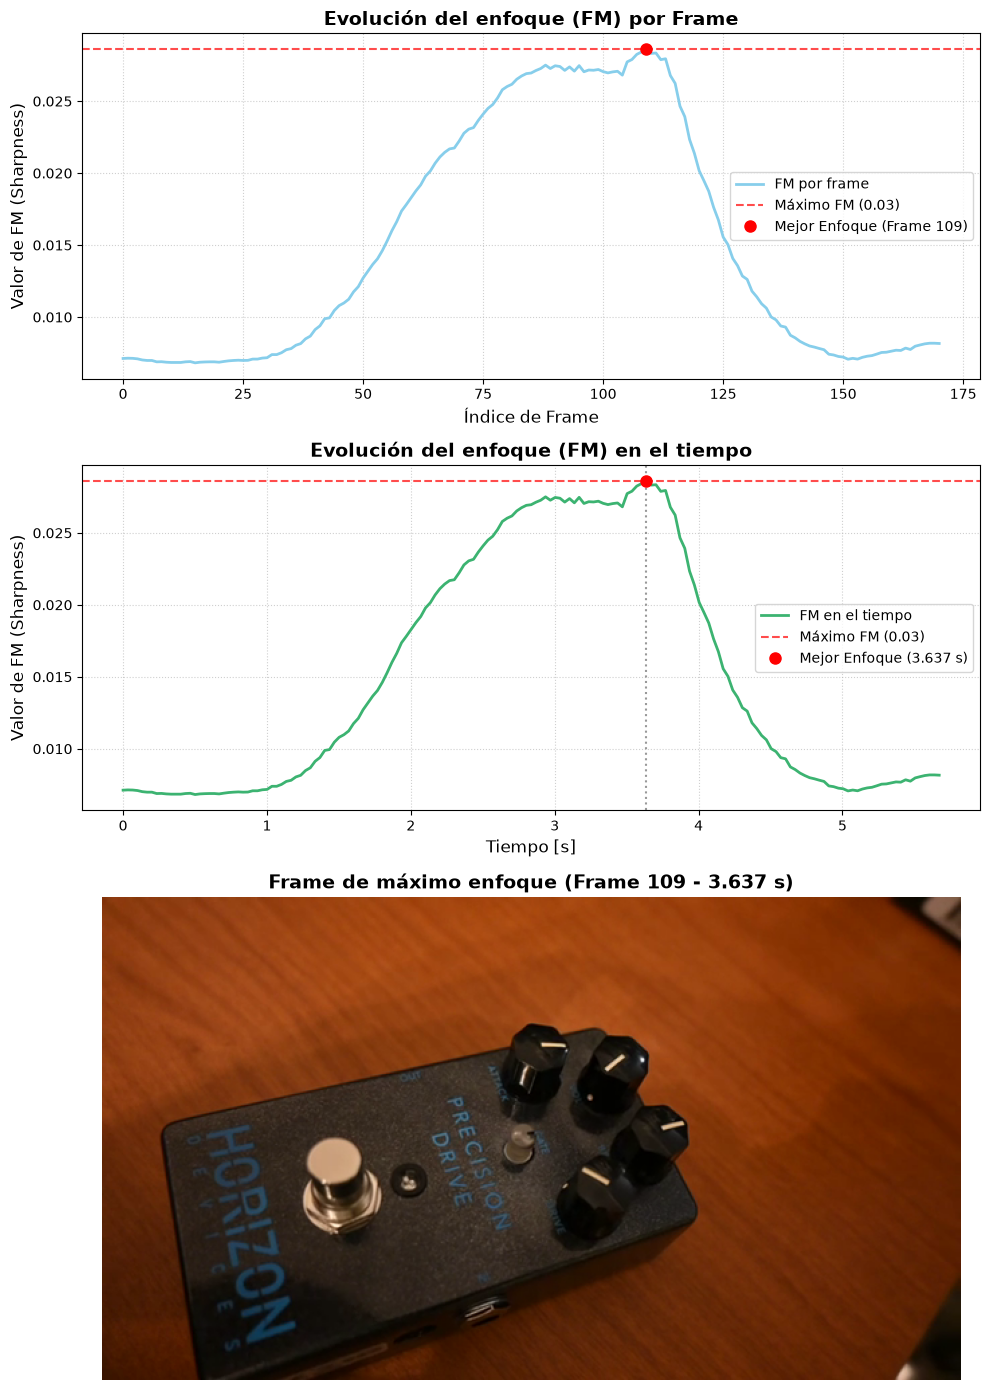

In [65]:
## Abre el video
video = cv.VideoCapture('Material/focus_video.mov')

# Genera un texto indicando si no pudo abrirlo o lo esta procesando.
if not video.isOpened():
    print("Error al abrir el archivo de video")
else:
    print("Procesando video y recolectando datos...")
    
    # Obtenemos la velocidad de captura del video.
    fps = video.get(cv.CAP_PROP_FPS)
    
    # Listas para almacenar los datos de la gráfica
    lista_segundos = []
    lista_frames = []
    lista_FM = []
    
    # Variables para rastrear el máximo
    maximo_FM = -1
    mejor_frame = -1
    contador_frames = 0
    
    while video.isOpened():
        ret, frame = video.read()

        if not ret:
            break
            
        # Calcula la métrica para el frame actual
        FM = fm_sharpness(frame)
        
        # Guardamos los datos para la gráfica
        segundo_actual = contador_frames / fps
        lista_segundos.append(segundo_actual)
        lista_frames.append(contador_frames)
        lista_FM.append(FM)
        
        # Rastrear el máximo absoluto
        if FM > maximo_FM:
            maximo_FM = FM
            mejor_frame = contador_frames
            
        contador_frames += 1

# Libera los recursos del video
video.release()

# Calculamos el segundo con la mejor metrica.
mejor_segundo = mejor_frame / fps

print("\n--- ¡Búsqueda Finalizada! ---")
print(f"El mejor enfoque está en el Frame: {mejor_frame}")
print(f"Que corresponde exactamente al Segundo: {mejor_segundo:.3f} s")
print(f"Valor máximo de FM: {maximo_FM:.3f}\n")

# Definimos los dos graficos a generar
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 14), gridspec_kw={'height_ratios': [1, 1, 1.4]})

# --- Gráfica 1: FM vs Frame ---
ax1.plot(lista_frames, lista_FM, label='FM por frame', color='skyblue', linewidth=2)
ax1.axhline(y=maximo_FM, color='red', linestyle='--', alpha=0.7, label=f'Máximo FM ({maximo_FM:.2f})')
ax1.plot(mejor_frame, maximo_FM, 'ro', markersize=8, label=f'Mejor Enfoque (Frame {mejor_frame})')
ax1.set_title('Evolución del enfoque (FM) por Frame', fontsize=14, fontweight='bold')
ax1.set_xlabel('Índice de Frame', fontsize=12)
ax1.set_ylabel('Valor de FM (Sharpness)', fontsize=12)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='best', fontsize=10)

# --- Gráfica 2: FM vs Tiempo (segundos) ---
ax2.plot(lista_segundos, lista_FM, label='FM en el tiempo', color='mediumseagreen', linewidth=2)
ax2.axhline(y=maximo_FM, color='red', linestyle='--', alpha=0.7, label=f'Máximo FM ({maximo_FM:.2f})')
ax2.axvline(x=mejor_segundo, color='gray', linestyle=':', alpha=0.8)
ax2.plot(mejor_segundo, maximo_FM, 'ro', markersize=8,label=f'Mejor Enfoque ({mejor_segundo:.3f} s)')
ax2.set_title('Evolución del enfoque (FM) en el tiempo', fontsize=14, fontweight='bold')
ax2.set_xlabel('Tiempo [s]', fontsize=12)
ax2.set_ylabel('Valor de FM (Sharpness)', fontsize=12)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='best', fontsize=10)

# --- Gráfica 3: Frame de máximo enfoque ---
ax3.imshow(cv.cvtColor(mejor_imagen, cv.COLOR_BGR2RGB))
ax3.set_title(f'Frame de máximo enfoque (Frame {mejor_frame} - {mejor_segundo:.3f} s)',
              fontsize=14, fontweight='bold')
ax3.axis('off')

plt.tight_layout()
plt.show()

### PUNTO 1.2 : Medición sobre una ROI ubicada en el centro del frame. Area de la ROI = 5 o 10% del area total del frame.


In [66]:
#Se define una roi en funcion de el tamaño de la imagen o video a procesar y el porcentaje elejido de area para la ROI.

def roi_central(alto, ancho, porcentaje_area_frame=5):
    por_area_frame = porcentaje_area_frame/100.0
    escala = np.sqrt(por_area_frame)
    rw, rh = int(round(ancho * escala)), int(round(alto * escala))
    x0, y0 = (ancho - rw) // 2, (alto - rh) // 2
    return x0, y0, x0 + rw, y0 + rh

In [67]:
# Se crea una funcion que permita facilmente cambiar el porcentaje del tamaño del ROI.

def analizar_roi(ruta_video, porcentaje_area):
    # Abre el video
    video = cv.VideoCapture(ruta_video)

    if not video.isOpened():
        raise IOError("Error al abrir el archivo de video")

    print(f"Procesando video con ROI del {porcentaje_area}% del área...")

    # Obtenemos la velocidad de captura del video.
    fps = video.get(cv.CAP_PROP_FPS)

    # Listas para almacenar los datos de la gráfica
    lista_segundos = []
    lista_frames = []
    lista_FM = []

    # Variables para rastrear el máximo
    maximo_FM = -1
    mejor_frame = -1
    mejor_imagen = None
    contador_frames = 0

    while True:
        ret, frame = video.read()
        if not ret:
            break

        # Recorta la ROI central y calcula la métrica sobre ella
        alto, ancho = frame.shape[:2]
        x0, y0, x1, y1 = roi_central(alto, ancho, porcentaje_area)
        roi = frame[y0:y1, x0:x1]
        FM = fm_sharpness(roi)

        # Guardamos los datos para la gráfica
        lista_segundos.append(contador_frames / fps)
        lista_frames.append(contador_frames)
        lista_FM.append(FM)

        # Rastrear el máximo absoluto
        if FM > maximo_FM:
            maximo_FM = FM
            mejor_frame = contador_frames
            mejor_imagen = frame.copy()

        contador_frames += 1

    # Libera los recursos del video
    video.release()

    mejor_segundo = mejor_frame / fps

    print("\n--- ¡Búsqueda Finalizada! ---")
    print(f"El mejor enfoque está en el Frame: {mejor_frame}")
    print(f"Que corresponde exactamente al Segundo: {mejor_segundo:.3f} s")
    print(f"Valor máximo de FM: {maximo_FM:.3f}\n")

    # Definimos los tres graficos a generar
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 14),
                                        gridspec_kw={'height_ratios': [1, 1, 1.4]})
    etiqueta = f'ROI {porcentaje_area}%'

    # --- Gráfica 1: FM vs Frame ---
    ax1.plot(lista_frames, lista_FM, label='FM por frame', color='skyblue', linewidth=2)
    ax1.axhline(y=maximo_FM, color='red', linestyle='--', alpha=0.7, label=f'Máximo FM ({maximo_FM:.2f})')
    ax1.plot(mejor_frame, maximo_FM, 'ro', markersize=8, label=f'Mejor enfoque (Frame {mejor_frame})')
    ax1.set_title(f'Evolución del enfoque (FM) por frame - {etiqueta}', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Frame', fontsize=12)
    ax1.set_ylabel('Valor de FM (Sharpness)', fontsize=12)
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend(loc='best', fontsize=10)

    # --- Gráfica 2: FM vs Tiempo (segundos) ---
    ax2.plot(lista_segundos, lista_FM, label='FM en el tiempo', color='mediumseagreen', linewidth=2)
    ax2.axhline(y=maximo_FM, color='red', linestyle='--', alpha=0.7, label=f'Máximo FM ({maximo_FM:.2f})')
    ax2.axvline(x=mejor_segundo, color='gray', linestyle=':', alpha=0.8)
    ax2.plot(mejor_segundo, maximo_FM, 'ro', markersize=8, label=f'Mejor enfoque ({mejor_segundo:.3f} s)')
    ax2.set_title(f'Evolución del enfoque (FM) en el tiempo - {etiqueta}', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Tiempo [s]', fontsize=12)
    ax2.set_ylabel('Valor de FM (Sharpness)', fontsize=12)
    ax2.grid(True, linestyle=':', alpha=0.6)
    ax2.legend(loc='best', fontsize=10)

    # --- Gráfica 3: Frame de máximo enfoque con la ROI marcada ---
    ax3.imshow(cv.cvtColor(mejor_imagen, cv.COLOR_BGR2RGB))
    ax3.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor='lime', linewidth=2.5))
    ax3.set_title(f'Frame de máximo enfoque (Frame {mejor_frame} - {mejor_segundo:.3f} s)',
                  fontsize=14, fontweight='bold')
    ax3.axis('off')

    plt.tight_layout()
    plt.show()

    return lista_frames, lista_segundos, lista_FM, mejor_frame, maximo_FM

Procesando video con ROI del 5% del área...

--- ¡Búsqueda Finalizada! ---
El mejor enfoque está en el Frame: 111
Que corresponde exactamente al Segundo: 3.704 s
Valor máximo de FM: 0.466



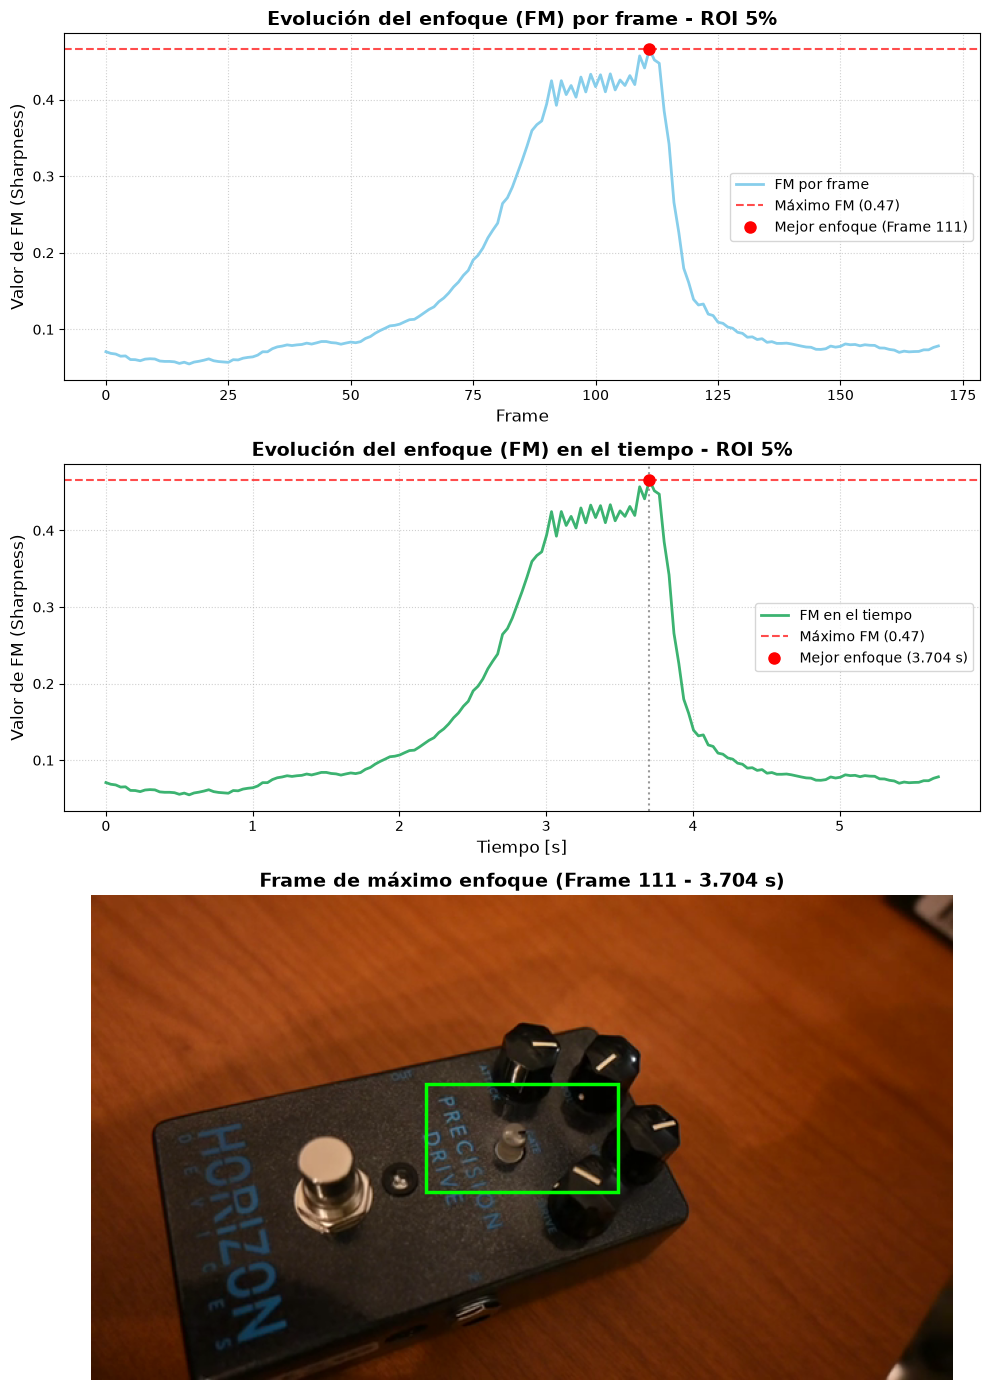

In [68]:
roi_5  = analizar_roi('Material/focus_video.mov', 5)

Procesando video con ROI del 10% del área...

--- ¡Búsqueda Finalizada! ---
El mejor enfoque está en el Frame: 111
Que corresponde exactamente al Segundo: 3.704 s
Valor máximo de FM: 0.359



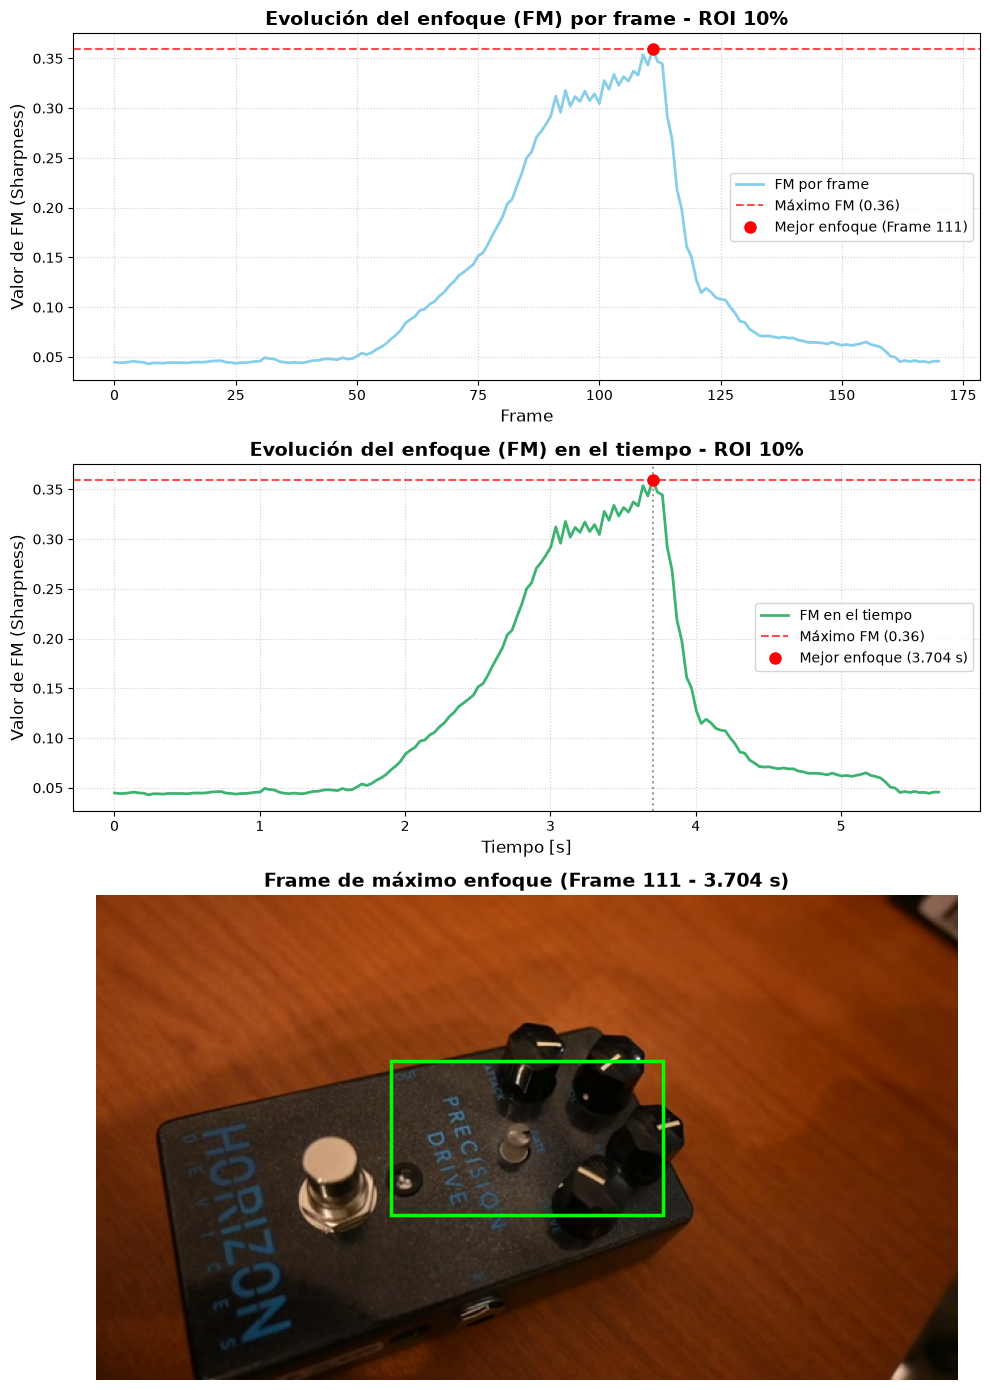

In [69]:
roi_10 = analizar_roi('Material/focus_video.mov', 10)

### PUNTO EXTRA : Aplicar unsharp masking para expandir la zona de enfoque y devolver.

In [70]:
def unsharp_masking(imagen, sigma=2.0, k=1.5):
    # Obtenemos la imagen desenfocada con un filtro gaussiano.
    desenfocada = cv.GaussianBlur(imagen, (0, 0), sigma)
    # imagen_final =  original + k*(original - desenfocada) = (1+k)*original - k*desenfocada
    imagen_realsada = cv.addWeighted(imagen, 1 + k, desenfocada, -k, 0)
    return imagen_realsada

In [71]:
def analizar_roi_usm(ruta_video, porcentaje_area, sigma=2.0, k=1.5):
    # Abre el video
    video = cv.VideoCapture(ruta_video)

    if not video.isOpened():
        raise IOError("Error al abrir el archivo de video")

    print(f"Procesando video con ROI del {porcentaje_area}% del área "
          f"(USM: sigma={sigma}, k={k})...")

    # Obtenemos la velocidad de captura del video.
    fps = video.get(cv.CAP_PROP_FPS)

    # Listas para almacenar los datos de la gráfica
    lista_segundos = []
    lista_frames = []
    lista_FM = []
    lista_FM_usm = []

    # Variables para rastrear el máximo de cada curva
    maximo_FM, mejor_frame, mejor_imagen = -1, -1, None
    maximo_FM_usm, mejor_frame_usm, mejor_imagen_usm = -1, -1, None
    contador_frames = 0

    while True:
        ret, frame = video.read()
        if not ret:
            break

        # Coordenadas de la ROI central
        alto, ancho = frame.shape[:2]
        x0, y0, x1, y1 = roi_central(alto, ancho, porcentaje_area)

        # FM de la ROI original
        FM = fm_sharpness(frame[y0:y1, x0:x1])

        # FM de la ROI realzada: se aplica USM al frame completo y después se recorta
        frame_usm = unsharp_masking(frame, sigma, k)
        FM_usm = fm_sharpness(frame_usm[y0:y1, x0:x1])

        # Guardamos los datos para la gráfica
        lista_segundos.append(contador_frames / fps)
        lista_frames.append(contador_frames)
        lista_FM.append(FM)
        lista_FM_usm.append(FM_usm)

        # Rastrear el máximo de cada curva y guardar su frame
        if FM > maximo_FM:
            maximo_FM, mejor_frame, mejor_imagen = FM, contador_frames, frame.copy()
        if FM_usm > maximo_FM_usm:
            maximo_FM_usm, mejor_frame_usm, mejor_imagen_usm = FM_usm, contador_frames, frame_usm.copy()

        contador_frames += 1

    # Libera los recursos del video
    video.release()

    mejor_segundo = mejor_frame / fps
    mejor_segundo_usm = mejor_frame_usm / fps

    print("\n--- ¡Búsqueda Finalizada! ---")
    print(f"Original -> Frame: {mejor_frame} | Segundo: {mejor_segundo:.3f} s | FM máx: {maximo_FM:.3f}")
    print(f"USM      -> Frame: {mejor_frame_usm} | Segundo: {mejor_segundo_usm:.3f} s | FM máx: {maximo_FM_usm:.3f}\n")

    # Grilla: las dos gráficas ocupan todo el ancho y las imágenes van en dos columnas
    fig, axs = plt.subplot_mosaic([['frames', 'frames'],['tiempo', 'tiempo'],['img','img_usm']], figsize=(12, 15), gridspec_kw={'height_ratios': [1, 1, 1.1]})
    ax1, ax2 = axs['frames'], axs['tiempo']
    ax3, ax4 = axs['img'], axs['img_usm']
    etiqueta = f'ROI {porcentaje_area}%'

    # --- Gráfica 1: FM vs Frame ---
    ax1.plot(lista_frames, lista_FM, label='FM original', color='skyblue', linewidth=2)
    ax1.plot(lista_frames, lista_FM_usm, label='FM con USM', color='orange', linewidth=2)
    ax1.axhline(y=maximo_FM, color='red', linestyle='--', alpha=0.5)
    ax1.axhline(y=maximo_FM_usm, color='darkorange', linestyle='--', alpha=0.5)
    ax1.plot(mejor_frame, maximo_FM, 'ro', markersize=8, label=f'Máx. original (Frame {mejor_frame}, FM {maximo_FM:.2f})')
    ax1.plot(mejor_frame_usm, maximo_FM_usm, 'o', color='darkorange', markersize=8, label=f'Máx. USM (Frame {mejor_frame_usm}, FM {maximo_FM_usm:.2f})')
    ax1.set_title(f'Evolución del enfoque (FM) por frame - {etiqueta}', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Frame', fontsize=12)
    ax1.set_ylabel('Valor de FM (Sharpness)', fontsize=12)
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend(loc='best', fontsize=10)

    # --- Gráfica 2: FM vs Tiempo (segundos) ---
    ax2.plot(lista_segundos, lista_FM, label='FM original', color='mediumseagreen', linewidth=2)
    ax2.plot(lista_segundos, lista_FM_usm, label='FM con USM', color='orange', linewidth=2)
    ax2.axhline(y=maximo_FM, color='red', linestyle='--', alpha=0.5)
    ax2.axhline(y=maximo_FM_usm, color='darkorange', linestyle='--', alpha=0.5)
    ax2.axvline(x=mejor_segundo, color='gray', linestyle=':', alpha=0.8)
    ax2.plot(mejor_segundo, maximo_FM, 'ro', markersize=8, label=f'Máx. original ({mejor_segundo:.3f} s)')
    ax2.plot(mejor_segundo_usm, maximo_FM_usm, 'o', color='darkorange', markersize=8, label=f'Máx. USM ({mejor_segundo_usm:.3f} s)')
    ax2.set_title(f'Evolución del enfoque (FM) en el tiempo - {etiqueta}', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Tiempo [s]', fontsize=12)
    ax2.set_ylabel('Valor de FM (Sharpness)', fontsize=12)
    ax2.grid(True, linestyle=':', alpha=0.6)
    ax2.legend(loc='best', fontsize=10)

    # --- Grafica 3: Imagen 1: mejor frame original ---
    ax3.imshow(cv.cvtColor(mejor_imagen, cv.COLOR_BGR2RGB))
    ax3.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0,
                            fill=False, edgecolor='lime', linewidth=2))
    ax3.set_title(f'Original - Frame {mejor_frame} ({mejor_segundo:.3f} s)', fontsize=12, fontweight='bold')
    ax3.axis('off')

    # --- Grafica 3: Imagen 2: mejor frame con USM ---
    ax4.imshow(cv.cvtColor(mejor_imagen_usm, cv.COLOR_BGR2RGB))
    ax4.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0,
                            fill=False, edgecolor='lime', linewidth=2))
    ax4.set_title(f'Con USM - Frame {mejor_frame_usm} ({mejor_segundo_usm:.3f} s)', fontsize=12, fontweight='bold')
    ax4.axis('off')

    plt.tight_layout()
    plt.show()

    return lista_frames, lista_segundos, lista_FM, lista_FM_usm


Procesando video con ROI del 10% del área (USM: sigma=2.0, k=1.5)...

--- ¡Búsqueda Finalizada! ---
Original -> Frame: 111 | Segundo: 3.704 s | FM máx: 0.359
USM      -> Frame: 109 | Segundo: 3.637 s | FM máx: 0.643



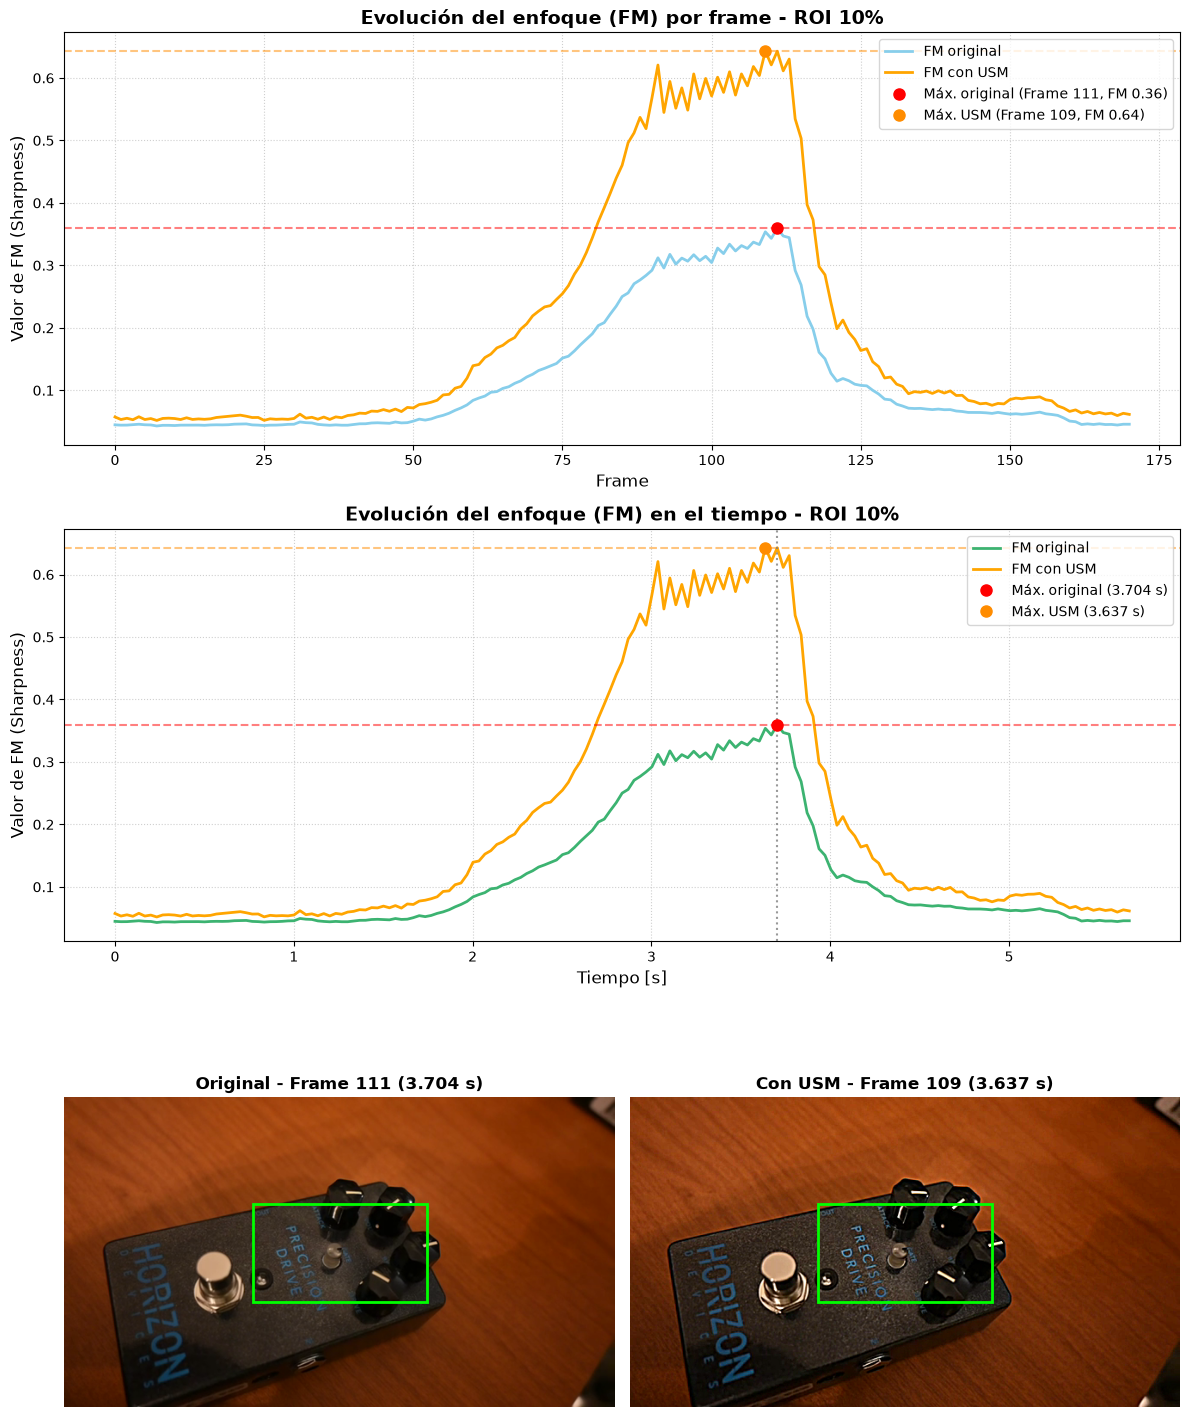

In [72]:
res_usm_10 = analizar_roi_usm('Material/focus_video.mov', 10)